In [1]:
import os

if not os.path.exists('thinkdsp.py'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkdsp.py
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/thinkplot.py

import thinkdsp
import thinkplot

# 10.1

In [4]:
if not os.path.exists('180960__kleeb__gunshot.wav'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/180960__kleeb__gunshot.wav
if not os.path.exists('92002__jcveliz__violin-origional.wav'):
    !wget https://github.com/AllenDowney/ThinkDSP/raw/master/code/92002__jcveliz__violin-origional.wav

--2026-05-19 22:29:48--  https://github.com/AllenDowney/ThinkDSP/raw/master/code/92002__jcveliz__violin-origional.wav
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/92002__jcveliz__violin-origional.wav [following]
--2026-05-19 22:29:48--  https://raw.githubusercontent.com/AllenDowney/ThinkDSP/master/code/92002__jcveliz__violin-origional.wav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 441044 (431K) [audio/wav]
Saving to: ‘92002__jcveliz__violin-origional.wav’

92002__jcveliz__vio 100%[===================>] 430.71K  --.-KB/s    in 0.03s   

2026-05-19 22:29:48

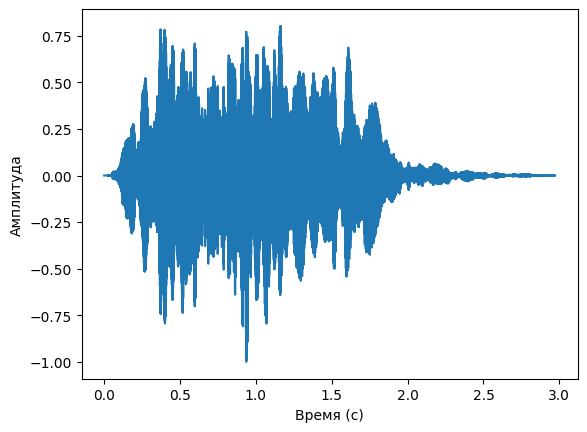

<Figure size 800x600 with 0 Axes>

In [5]:
import numpy as np

response = thinkdsp.read_wave('180960__kleeb__gunshot.wav')
start = 0.12
response = response.segment(start=start)
response.shift(-start)

# Обрезаем и дополняем нулями до степени двойки
response.truncate(2**16)
response.zero_pad(2**17)
response.normalize()

violin = thinkdsp.read_wave('92002__jcveliz__violin-origional.wav')
start = 0.11
violin = violin.segment(start=start)
violin.shift(-start)

# Обрезаем и дополняем нулями
violin.truncate(2**16)
violin.zero_pad(2**17)
violin.normalize()

# 3. Передаточная функция (ДПФ импульсной характеристики)
transfer = response.make_spectrum()

# 4. Спектр входного сигнала
spectrum = violin.make_spectrum()

# 5. Вычисление выходного сигнала через умножение спектров
output = (spectrum * transfer).make_wave()
output.normalize()

# 6. Визуализация результата
output.plot()
thinkplot.config(xlabel='Время (с)', ylabel='Амплитуда')
thinkplot.show()

# 10.2

In [3]:
import numpy as np
import os

# Импульсная характеристика из Open AIR

if not os.path.exists('bformat_IR_Position1_HolyTrin_M1acn.wav'):
    !wget /content/bformat_IR_Position1_HolyTrin_M1acn.wav
if not os.path.exists('852917__garuda1982__gentle-steady-spring-rain-city.wav'):
    !wget /content/852917__garuda1982__gentle-steady-spring-rain-city.wav

ir = thinkdsp.read_wave('bformat_IR_Position1_HolyTrin_M1acn.wav')

speech = thinkdsp.read_wave('852917__garuda1982__gentle-steady-spring-rain-city.wav')

speech = speech.segment(start=0, duration=30)

# Свёртка через БПФ
n = len(speech.ys) + len(ir.ys) - 1
n_fft = 2 ** int(np.ceil(np.log2(n)))

speech_padded = speech.copy()
speech_padded.zero_pad(n_fft)
ir_padded = ir.copy()
ir_padded.zero_pad(n_fft)

spectrum_speech = speech_padded.make_spectrum()
spectrum_ir = ir_padded.make_spectrum()
output_spec = (spectrum_speech * spectrum_ir).make_wave()
output_spec.truncate(n)
output_spec.normalize()

# График
thinkplot.plot(output_spec.ys[:10000])
thinkplot.config(xlabel='Отсчёт', ylabel='Амплитуда')
thinkplot.show()

# Прослушивание (опционально)
output_spec.make_audio()

Output hidden; open in https://colab.research.google.com to view.